# Week 5 Predicting Profitability in Logistics Operations Using ML

**Author:** Maryi Tatiana Palacios Giraldo  
**Course:** MSDS692_S40_Data Science Practicum

Data Understanding

The dataset represents an integrated logistics operations system combining shipment tracking, financial performance, and operational metrics across multiple transportation modes (air, sea, and truck). It includes detailed information on shipment routes, timing variables (ETD, ETA, ATA), financial indicators (revenue, cost, profit), and cargo characteristics (weight, volume, TEU).

The dataset also contains multiple entity-level variables such as suppliers, importers, and local clients, which provide contextual information for each shipment.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
pip install xlrd

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
df = pd.read_excel(r'C:\Users\tatiana.palacios\OneDrive - Gallagher Transport International\Documents\Tatiana\My docs\Practicum\Dataset\declaration.xlsx')

In [4]:
print(df.head())

  Declaration ID Cancel Trans Dec. Type Mode   Br Standalone  # Inv. Headers  \
0      B00001490      N   AIR       IMP  NCT  DEN          Y               1   
1      B00001491      N   TRK       IMP  NCT  SFO          Y               1   
2      B00001492      N   NaN       EXP  NaN  SFO          Y               0   
3      B00001493      N   SEA       IMP  CNT  IAH          Y               1   
4      B00001494      N   SEA       IMP  NCT  IAH          Y               1   

   # Inv. Lines Origin  ...          Job Opened  Revenue   WIP Total Income  \
0             1  CHBSL  ... 2025-12-01 15:13:00   235.00   NaN       235.00   
1             1  JPTYO  ... 2025-12-01 15:15:00      NaN   NaN          NaN   
2             0    NaN  ... 2025-12-01 15:16:00      NaN  3.28         3.28   
3             1  AOLAD  ... 2025-12-01 15:18:00   751.52   NaN       751.52   
4             1  BRSAO  ... 2025-12-01 16:01:00  1214.06   NaN      1214.06   

     Cost Accrual Total Expense Job Profit C

In [5]:
df.tail()

,Declaration ID,Cancel,Trans,Dec. Type,Mode,Br,Standalone,# Inv. Headers,# Inv. Lines,Origin,...,Job Opened,Revenue,WIP,Total Income,Cost,Accrual,Total Expense,Job Profit,Ctr Count,TEU
8265,S00001288,N,AIR,EXP,NCT,DEN,N,1,1,USPE4,...,2026-04-17 18:35:00,770.0,8.35,778.35,-356.35,NaN,-356.35,422.00,0,0.0
8266,S00001290,N,ROA,EXP,NaN,DEN,N,1,1,USBUF,...,2026-04-29 16:59:00,165.0,NaN,165.00,-8.35,NaN,-8.35,156.65,0,0.0
8267,S00001293,N,TRK,EXP,NCT,DEN,N,1,1,USPHN,...,2026-05-15 15:39:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0
8268,S00001294,N,SEA,EXP,CNT,DEN,N,1,1,USHOU,...,2026-05-18 16:07:00,200.0,NaN,200.00,-12.75,NaN,-12.75,187.25,1,2.3
8269,S00001298,N,SEA,EXP,CNT,DEN,N,1,1,USOLS,...,2026-05-28 18:28:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.0


In [6]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 8270 entries, 0 to 8269
Data columns (total 49 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Declaration ID     8270 non-null   str           
 1   Cancel             8270 non-null   str           
 2   Trans              7875 non-null   str           
 3   Dec. Type          8270 non-null   str           
 4   Mode               7824 non-null   str           
 5   Br                 8270 non-null   str           
 6   Standalone         8270 non-null   str           
 7   # Inv. Headers     8270 non-null   int64         
 8   # Inv. Lines       8270 non-null   int64         
 9   Origin             7804 non-null   str           
 10  Final Dest.        7920 non-null   str           
 11  Load               7793 non-null   str           
 12  Arrival            7941 non-null   str           
 13  Origin ETD         6649 non-null   datetime64[us]
 14  Dest. ETA          

In [7]:
df.describe()

,# Inv. Headers,# Inv. Lines,Origin ETD,Dest. ETA,Load ATD,Arrival ATA,Dec. Registered,Weight,Volume,Packs,Job Opened,Revenue,WIP,Total Income,Cost,Accrual,Total Expense,Job Profit,Ctr Count,TEU
count,8270.000000,8270.000000,6649,7613,7658,7653,8270,8270.000000,8270.000000,8270.00000,8270,6948.000000,1292.000000,8204.000000,8158.000000,1036.000000,8203.000000,8264.000000,8270.000000,8270.000000
mean,0.927207,8.696372,2026-02-16 13:12:42.538727,2026-03-12 20:36:19.048995,2026-02-15 07:01:23.677200,2026-03-10 09:36:09.031752,2026-02-25 22:33:59.354292,9849.974870,24.667200,346.56058,2026-02-25 21:45:10.251511,5966.974290,3002.420139,5526.287688,-4768.599712,-4505.491467,-5311.462344,213.908347,0.462273,0.715175
min,0.000000,0.000000,2020-01-22 00:00:00,2025-04-24 00:00:00,2025-01-25 00:00:00,2025-04-21 00:00:00,2025-12-01 14:28:00,0.000000,0.000000,0.00000,2025-10-30 17:08:00,30.000000,1.150000,3.280000,-215878.690000,-103629.810000,-216162.050000,-8642.950000,0.000000,0.000000
25%,1.000000,1.000000,2026-01-02 00:00:00,2026-01-22 00:00:00,2025-12-29 06:00:00,2026-01-20 00:00:00,2026-01-08 23:15:00,168.000000,0.000000,1.00000,2026-01-08 22:19:15,270.000000,9.950000,183.580000,-4378.920000,-7797.672500,-6899.800000,107.050000,0.000000,0.000000
50%,1.000000,1.000000,2026-02-17 00:00:00,2026-03-11 00:00:00,2026-02-14 00:00:00,2026-03-09 00:00:00,2026-02-24 23:40:30,1510.000000,0.000000,6.00000,2026-02-24 23:13:00,899.510000,9.950000,746.500000,-270.010000,-400.000000,-482.790000,150.000000,0.000000,0.000000
75%,1.000000,1.000000,2026-04-07 00:00:00,2026-05-01 00:00:00,2026-04-06 00:00:00,2026-04-29 00:00:00,2026-04-14 21:44:00,13525.500000,0.000000,128.00000,2026-04-14 21:35:15,7015.440000,7000.240000,7033.100000,-9.950000,-110.500000,-9.950000,253.000000,1.000000,1.000000
max,31.000000,9956.000000,2026-12-12 00:00:00,2028-04-29 00:00:00,2026-07-19 00:00:00,2026-08-23 00:00:00,2026-05-30 14:43:00,999999.999000,120000.000000,83457.00000,2026-05-30 14:43:00,216592.410000,88476.740000,216592.410000,5531.160000,15032.400000,0.020000,5211.040000,23.000000,52.000000
std,1.046285,183.019364,NaN,NaN,NaN,NaN,NaN,40497.682726,1360.841362,2478.98673,NaN,14027.022707,6446.257385,13200.980621,12929.197868,8368.710780,13119.693279,343.426552,0.885768,1.758033


Initial insights:

- The dataset contains 5,795 rows and 49 columns
- Mix of:
- Numerical variables (Revenue, Cost, Weight, TEU, etc.)
- Categorical variables (Mode, Origin, Supplier, etc.)
- Date variables (ETD, ETA, ATA, Job Opened)
- Some variables have significant missing values

In [8]:
df.columns

Index(['Declaration ID', 'Cancel', 'Trans', 'Dec. Type', 'Mode', 'Br',
       'Standalone', '# Inv. Headers', '# Inv. Lines', 'Origin', 'Final Dest.',
       'Load', 'Arrival', 'Origin ETD', 'Dest. ETA', 'Load ATD', 'Arrival ATA',
       'Dec. Registered', 'Supplier', 'Supplier Name', 'Importer',
       'Importer Name', 'House', 'Master', 'Vessel', 'Voy./Flt.', 'Weight',
       'Wt. UQ', 'Volume', 'Vol. UQ', 'Packs', 'Pack Type', 'BR', 'Dept',
       'Local Client', 'Local Client Name', 'Job Sales Rep', 'Job Operator',
       'Status', 'Job Opened', 'Revenue', 'WIP', 'Total Income', 'Cost',
       'Accrual', 'Total Expense', 'Job Profit', 'Ctr Count', 'TEU'],
      dtype='str')

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_pct.sort_values(ascending=False)

Accrual              87.472793
WIP                  84.377267
House                51.692866
Job Sales Rep        49.830713
Vessel               39.842805
Origin ETD           19.600967
Revenue              15.985490
Pack Type            13.518742
Voy./Flt.            11.995163
Vol. UQ               9.600967
Dest. ETA             7.944377
Arrival ATA           7.460701
Load ATD              7.400242
Master                6.372430
Load                  5.767836
Supplier              5.719468
Supplier Name         5.719468
Origin                5.634825
Mode                  5.392987
Trans                 4.776300
Final Dest.           4.232164
Arrival               3.978235
Importer              3.446191
Importer Name         3.446191
Wt. UQ                2.406288
Cost                  1.354293
Total Expense         0.810157
Total Income          0.798065
Local Client          0.133011
Local Client Name     0.133011
Job Profit            0.072551
Declaration ID        0.000000
# Inv. L

Findings:

Highly missing variables:
- WIP (~95%)
- Accrual (~89%)
- Job Sales Rep (~54%)
- House (~49%)
- Vessel (~41%)

Low missing values:
- Revenue, Cost, Total Expense (<6%)

Minimal missing values:
- Most operational and financial variables (<1%)

# Handling missing values

## Remove columns with a high number of missing values:

In [11]:
cols_drop = [
    'WIP', 'Accrual', 'House',
    'Job Sales Rep', 'Vessel',
    'Master', 'Vol. UQ', 'Voy./Flt.'
]

df = df.drop(columns=cols_drop)

Variables with extremely high missing rates or low analytical value were removed to improve data quality and reduce noise:

- WIP and Accrual: mostly missing (>85%), not reliable for modeling
- House, Master, Vessel, Voy./Flt. and Vol. UQ: not very relevant for the analysis

## Handling Categorical Variables with Unknown

In [12]:
cat_cols = [
    'Mode', 'Origin', 'Final Dest.', 'Supplier', 'Supplier Name',
    'Importer', 'Importer Name', 'Pack Type', 'Load', 'Local Client' , 'Local Client Name' ,
    'Wt. UQ', 'Trans', 'Arrival'
]

for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

Categorical variables were imputed using a placeholder value "Unknown":

- Preserves information about missing categories
- Prevents loss of records
- Standard practice for categorical imputation in logistics datasets

## Numerical variables with the mean

In [13]:
numeric_cols = ['Revenue', 'Cost', 'Total Expense', 'Total Income', 'Job Profit']

for col in numeric_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

Financial variables were imputed using the median to reduce the impact of outliers:

- Median is robust to extreme values (important due to high variance in revenue/cost)
- Maintains distribution integrity


In [14]:
df = df.dropna(subset=['Arrival ATA'])

Additionally, the Arrival ATA variable had very few missing values and was handled by removing incomplete records.

## Date Variables: Adjust Format

In [15]:

date_cols = [
    'Origin ETD', 'Dest. ETA',
    'Load ATD', 'Arrival ATA',
    'Dec. Registered', 'Job Opened'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')


In [16]:

df['Origin ETD'] = df['Origin ETD'].fillna(df['Load ATD'])
df['Dest. ETA'] = df['Dest. ETA'].fillna(df['Arrival ATA'])


Missing date values were handled using logical imputation. For example, when the estimated departure date (ETD) was missing, it was replaced with the actual departure date (ATD), since both represent closely related shipment events. Similarly, missing estimated arrival dates (ETA) were replaced with actual arrival dates (ATA). This approach preserves temporal consistency while avoiding unnecessary data loss.

In [17]:
df.isnull().sum().sum()

np.int64(35)

In [18]:
cat_cols = [
    'Trans', 'Mode', 'Origin', 'Final Dest.', 'Load', 'Arrival',
    'Supplier', 'Supplier Name',
    'Importer', 'Importer Name',
    'Pack Type',
    'Dept', 'Local Client', 'Local Client Name',
    'Job Operator', 'Status',
    'Wt. UQ', 'Br',
]

In [19]:
for col in cat_cols:
    df[col] = df[col].astype('category')

Several variables originally stored as object type were identified as categorical variables representing discrete operational and logistical attributes within the shipment process. These include transportation mode, geographic origin and destination, suppliers, importers, operational status, and packaging types.

To support more effective exploratory analysis, these variables were converted to the category data type in pandas.

## Binary Variables

In [20]:
df['Cancel'] = df['Cancel'].map({'Y':1,'N':0})
df['Standalone'] = df['Standalone'].map({'Y':1,'N':0})


Convert to Categorical

In [21]:
cat_cols_final = [
    'Trans', 'Mode', 'Origin', 'Final Dest.', 'Load', 'Arrival',
    'Supplier', 'Supplier Name', 'Importer', 'Importer Name',
    'Pack Type', 'Dept', 'Local Client', 'Local Client Name',
    'Job Operator', 'Status', 'Wt. UQ', 'Br'
]

for col in cat_cols_final:
    if col in df.columns:
        df[col] = df[col].astype('category')

In addition to categorical transformations, binary variables were identified and encoded into numerical format to ensure compatibility with statistical analysis and potential predictive modeling tasks. Specifically, variables representing yes/no conditions were transformed into binary indicators.

In [22]:

missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]

print(missing_counts)



Origin ETD    17
Load ATD      18
dtype: int64


Time-related variables such as ETD and ATD were retained because they provide valuable information for future feature engineering, particularly for calculating transit times and delays, which are relevant for predictive modeling.

In [23]:
df = df.rename(columns={

    '# Inv. Headers': 'Invoice Headers',
    '# Inv. Lines': 'Invoice Lines',

    'Wt. UQ': 'Weight Unit',
    'Vol. UQ': 'Volume Unit',

    'Trans': 'Transport Type',
    'Mode': 'Mode',
    'Br': 'Branch',

    'Dec. Type': 'Dec. Type',

    'Arrival': 'Arrival Port',
    'Origin': 'Origin Port',
    'Final Dest.': 'Final Destination',
    'Load': 'Load Port',

    'Voy./Flt.': 'Voyage/Flight',

    'Ctr Count': 'Container Count',

    'Job Opened': 'Job Opened',
    'Job Operator': 'Job Operator',

    'Local Client': 'Local Client',
    'Local Client Name': 'Local Client Name',

    'Supplier': 'Supplier',
    'Supplier Name': 'Supplier Name',

    'Importer': 'Importer',
    'Importer Name': 'Importer Name'
})

Column names were selectively standardized to improve readability during analysis.

The dataset has been successfully cleaned, structured, and transformed into an analysis-ready format. Variables were correctly assigned to categorical, numerical, binary, and datetime types based on their semantic meaning within the logistics domain. This ensures both computational efficiency and analytical interpretability, making the dataset suitable for exploratory data analysis and subsequent forecasting modeling.

# EDA


# 1. SHIPMENT CHARACTERISTICS

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1.1. Declarations processed per month

In [25]:

df["reg_month"] = df["Dec. Registered"].dt.to_period("M")
df["reg_year"] = df["Dec. Registered"].dt.year
df["reg_day"] = df["Dec. Registered"].dt.day

df["reg_month"] = df["Dec. Registered"].dt.to_period("M")
df["reg_year"] = df["Dec. Registered"].dt.year
df["reg_day"] = df["Dec. Registered"].dt.day


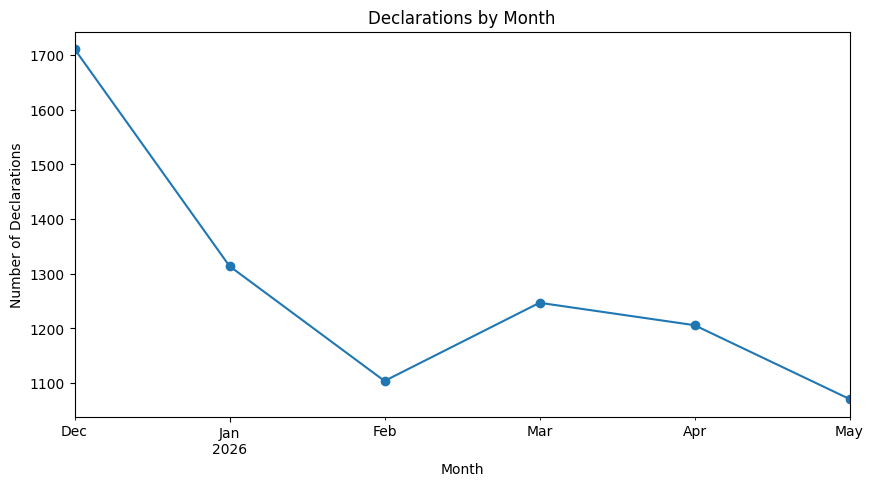

In [26]:
monthly_decl = df.groupby("reg_month").size()

monthly_decl.plot(marker="o", figsize=(10,5))
plt.title("Declarations by Month")
plt.ylabel("Number of Declarations")
plt.xlabel("Month")
plt.show()


This chart shows the number of declarations over time. We observe a peak in December, followed by a significant decline in early months, suggesting seasonal demand patterns. Although there is a partial recovery in March, the overall trend remains lower compared to the year-end peak.

## 1.2. Transport Type Distribution

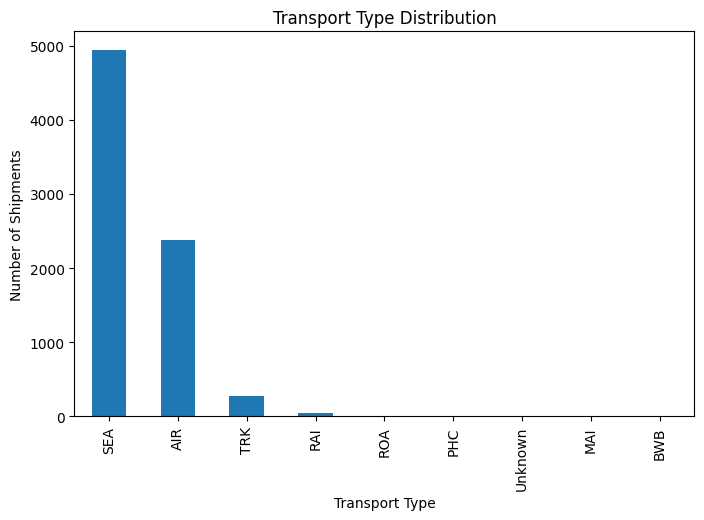

In [27]:
df["Transport Type"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Transport Type Distribution")
plt.ylabel("Number of Shipments")
plt.xlabel("Transport Type")
plt.show()


The transport type distribution shows a strong dominance of sea shipments, followed by air transport. Other modes contribute minimally to overall operations. This indicates a high dependency on specific transport types, which may introduce operational risks, particularly in modes prone to delays such as sea transport.

Transport Type Reference:

AIR – Air Transport  
SEA – Sea Transport  
TRK – Truck  
RAI – Rail  
ROA – Road  
MAI – Mail  
PHC – Hand Carry  

## 1.3. Branch Distribution

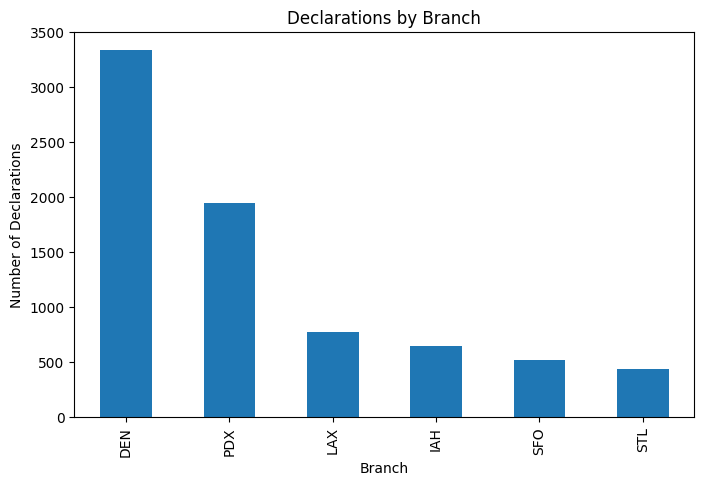

In [28]:
df["Branch"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Declarations by Branch")
plt.ylabel("Number of Declarations")
plt.show()

This chart shows the distribution of declarations across branches. The Denver branch dominates operations, handling a significantly higher volume than all other locations. Portland represents a secondary hub, while the remaining branches contribute at a much smaller scale. This concentration may introduce operational risk and makes overall performance highly dependent on a single branch.

Branch Reference:

DEN – Denver  
PDX – Portland  
LAX – Los Angeles  
IAH – Houston  
SFO – San Francisco  
STL – St. Louis  

# 2. PROFITABILITY ANALYSIS

## 2.1 Monthly Profit Trend

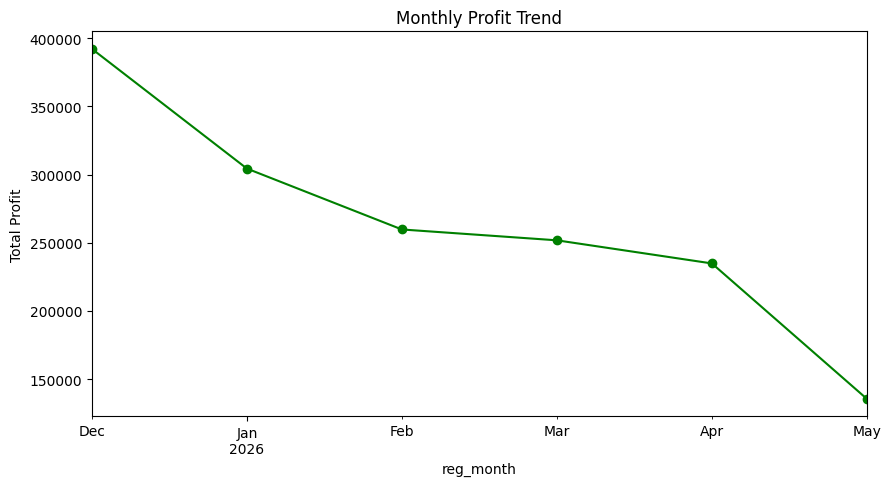

In [29]:
monthly_profit = df.groupby("reg_month")["Job Profit"].sum()

monthly_profit.plot(marker="o", color="green", figsize=(10,5))
plt.title("Monthly Profit Trend")
plt.ylabel("Total Profit")
plt.show()

The monthly profit trend shows a clear decline after December, which represents the peak in profitability. This pattern closely follows the decrease in operational activity, indicating that profit is strongly linked to shipment volume. However, the sharp drop observed in later months also suggests that operational efficiency and cost factors may be affecting overall profitability.

## 2.2 Profit by Branch

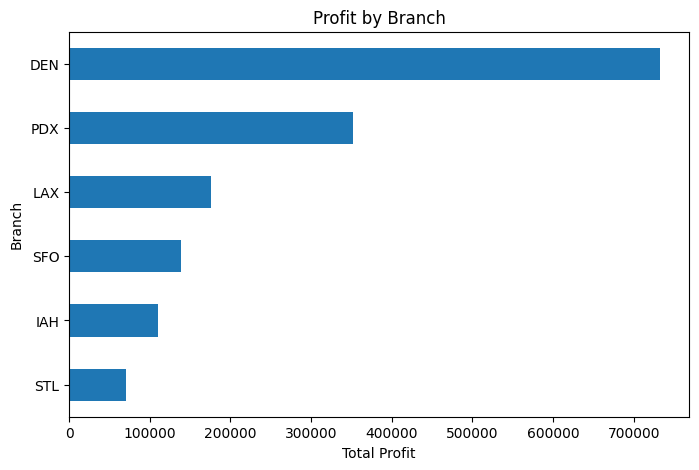

In [30]:
df.groupby("Branch")["Job Profit"].sum().sort_values().plot(kind="barh", figsize=(8,5))
plt.title("Profit by Branch")
plt.xlabel("Total Profit")
plt.show()

The profit distribution by branch shows that Denver generates the highest profit by a large margin, followed by Portland. This aligns with the earlier observation that Denver also handles the highest operational volume, indicating a strong relationship between activity and profitability. However, this concentration suggests a dependency on a single branch, which may introduce operational and financial risk.

## 2.3 Revenue vs Profit

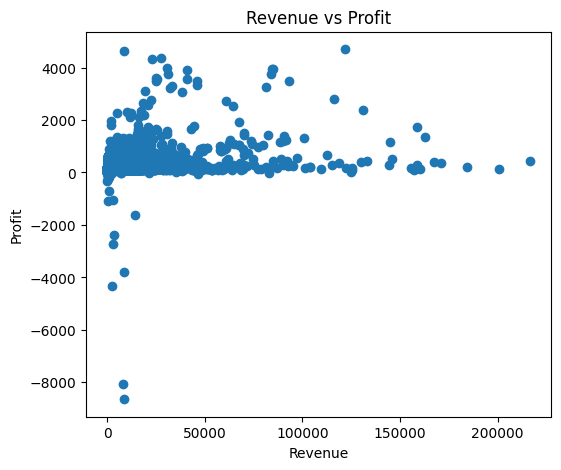

In [31]:
plt.figure(figsize=(6,5))
plt.scatter(df["Revenue"], df["Job Profit"])
plt.title("Revenue vs Profit")
plt.xlabel("Revenue")
plt.ylabel("Profit")
plt.show()

The scatter plot shows the relationship between revenue and profit. While there is a general positive trend, the relationship is relatively weak. Notably, several cases exhibit high revenue but low or even negative profit, indicating that revenue alone does not guarantee profitability. This suggests that cost management and operational efficiency play a critical role in financial performance.

## 2.4 Profit by Transport Type

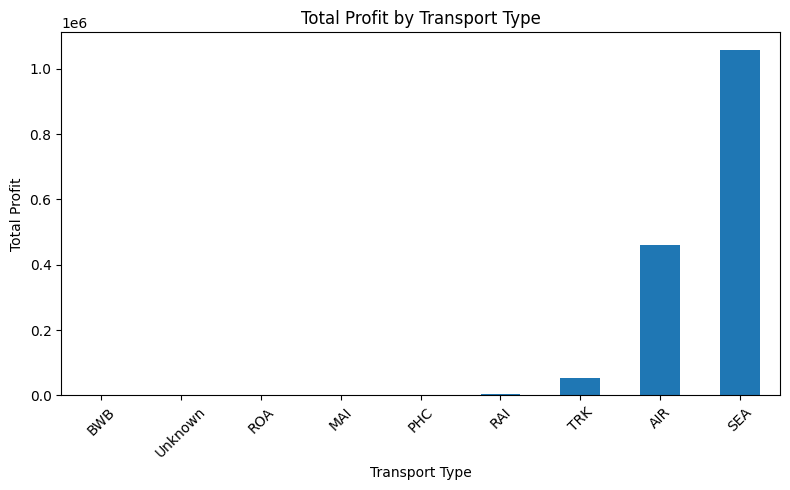

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

df.groupby("Transport Type")["Job Profit"].sum().sort_values().plot(
    kind="bar"
)

plt.title("Total Profit by Transport Type")
plt.xlabel("Transport Type")
plt.ylabel("Total Profit")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [33]:
df["Job Profit"].describe()

count    7653.000000
mean      206.234286
std       326.678208
min     -8642.950000
25%       107.050000
50%       150.000000
75%       244.050000
max      4699.270000
Name: Job Profit, dtype: float64

<Axes: xlabel='Job Profit'>

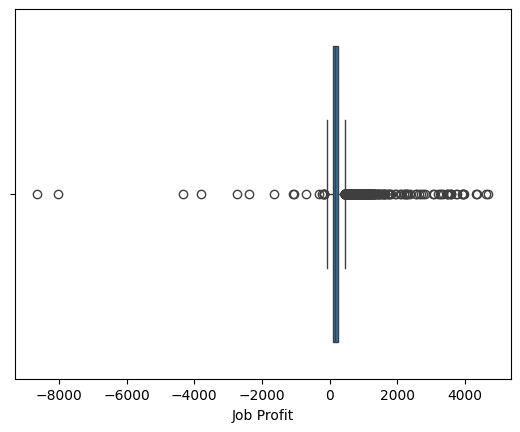

In [34]:
sns.boxplot(x=df["Job Profit"])

# 3. DELAY ANALYSIS

## 3.1 Delay Distribution

In [35]:
df["Delay"] = (df["Arrival ATA"] - df["Dest. ETA"]).dt.days

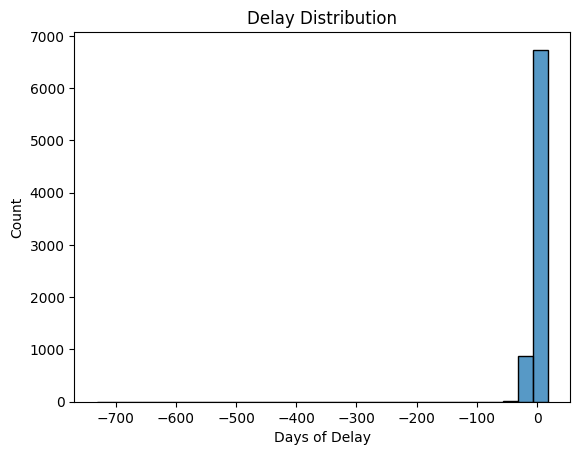

In [36]:
sns.histplot(df["Delay"], bins=30)
plt.title("Delay Distribution")
plt.xlabel("Days of Delay")
plt.show()

The delay distribution shows that most shipments are concentrated around zero, indicating that operations are generally on time. However, the presence of extreme negative outliers suggests potential data inconsistencies or anomalies. These values may need to be addressed before modeling to ensure accurate predictions.

## 3.2 Delay by Transport Type

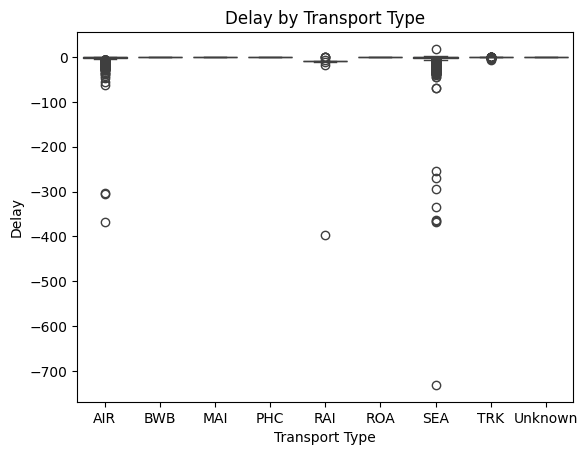

In [37]:
sns.boxplot(x="Transport Type", y="Delay", data=df)
plt.title("Delay by Transport Type")
plt.show()

The analysis of delay by transport type shows that most shipments across all modes are concentrated around zero delay. However, sea transport exhibits significantly higher variability and extreme outliers, indicating greater operational risk and inconsistency. In contrast, air transport appears more stable. These differences highlight the importance of transport type as a key factor in delay prediction.

## 3.3 Delay vs Profit

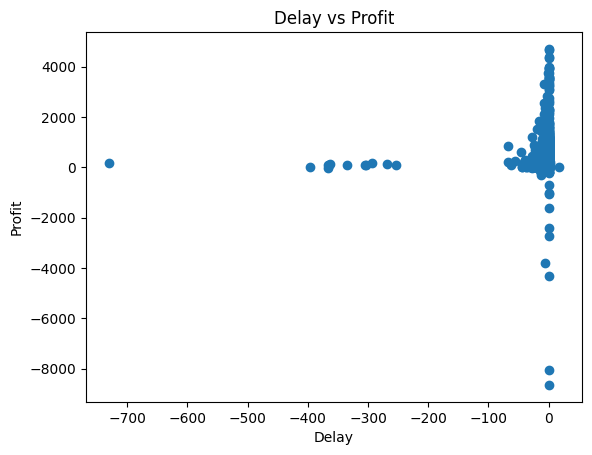

In [38]:
plt.scatter(df["Delay"], df["Job Profit"])
plt.title("Delay vs Profit")
plt.xlabel("Delay")
plt.ylabel("Profit")
plt.show()


The relationship between delay and profit shows no strong linear pattern. While most shipments are near zero delay, profitability varies widely, including both high profits and losses. This indicates that delay alone does not explain financial performance. The variability suggests that other factors, such as cost and operational efficiency, play a critical role. Additionally, the presence of extreme outliers highlights the need for further data treatment before modeling.

## Shipments with Delay

In [39]:
total_shipments = len(df)

delayed_shipments = (df["Delay"] > 0).sum()

print("Total shipments:", total_shipments)
print("Shipments with delay:", delayed_shipments)

Total shipments: 7653
Shipments with delay: 6


Only 0.08% of shipments experienced delays, indicating a highly imbalanced distribution. This limits the predictive value of delay modeling, as most observations correspond to on-time deliveries.

# Heatmap

In [40]:
numeric_cols = [
    "Invoice Headers",
    "Invoice Lines",
    "Weight",
    "Volume",
    "Packs",
    "Revenue",
    "Total Income",
    "Cost",
    "Total Expense",
    "Job Profit",
    "Container Count",
    "TEU"
]

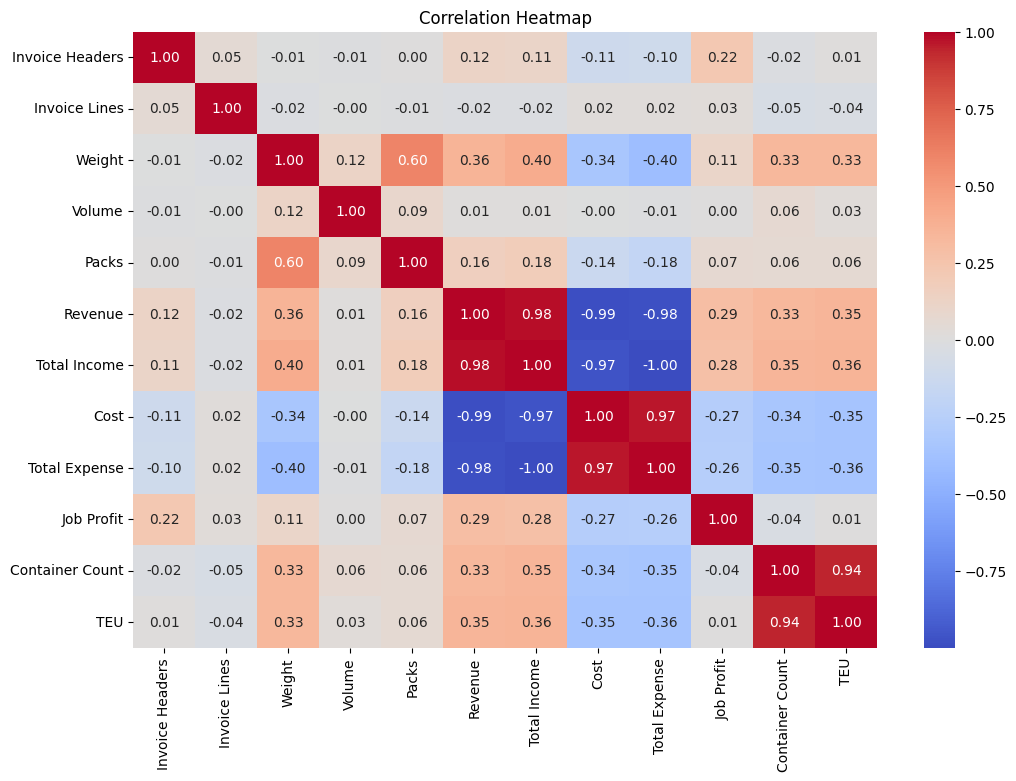

In [41]:
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()


The correlation heatmap shows strong relationships between financial variables. Revenue is highly correlated with total income and inversely related to costs and expenses. However, revenue has only a moderate correlation with profit, indicating that high revenue does not always translate into high profitability. Additionally, shipment size variables such as weight and packs show moderate relationships with revenue.

# Week 6: Feature Engineering   

Feature engineering was conducted to transform raw operational data into meaningful predictors, focusing on temporal patterns, financial efficiency, shipment characteristics, and operational complexity

## Temporal Features

In [83]:
df["month"] = df["Dec. Registered"].dt.month

In [84]:
df["weekday"] = df["Dec. Registered"].dt.weekday

In [85]:
df["quarter"] = df["month"].apply(lambda x: (x - 1) // 3 + 1)

In [86]:
df["is_weekend"] = df["weekday"].isin([5, 6]).astype(int)

In [55]:
df[["Dec. Registered", "month"]].head(5)

,Dec. Registered,month
0,2025-12-01 15:13:00,12
1,2025-12-01 15:15:00,12
3,2025-12-01 15:18:00,12
4,2025-12-01 16:01:00,12
5,2025-12-01 16:07:00,12


Temporal features were created from the shipment registration date to capture seasonal and operational patterns. Variables such as month, weekday, quarter, and weekend indicators were used to reflect time-based variations that may influence shipment activity and profitability.

## Logistical Time Features

## Transit Time

In [57]:
df["transit_time"] = (df["Arrival ATA"] - df["Origin ETD"]).dt.days

In [59]:
df[["Origin ETD", "Arrival ATA", "transit_time"]].head(5)

,Origin ETD,Arrival ATA,transit_time
0,2025-11-27,2025-11-27,0.0
1,2025-11-26,2025-11-29,3.0
3,2025-10-04,2025-12-01,58.0
4,2025-11-19,2025-12-02,13.0
5,2025-10-15,2025-11-30,46.0


Transit time was calculated as the number of days between the estimated departure date and the actual arrival date, representing the total duration of the shipment process. This feature captures transportation efficiency and is expected to influence profitability, as longer transit times may increase operational costs and reduce margins.

## Handling Time


In [45]:
df["handling_time"] = (df["Load ATD"] - df["Origin ETD"]).dt.days

In [61]:
df[["Origin ETD", "Load ATD", "handling_time"]].head(5)

,Origin ETD,Load ATD,handling_time
0,2025-11-27,2025-11-27,0.0
1,2025-11-26,2025-11-26,0.0
3,2025-10-04,2025-10-04,0.0
4,2025-11-19,2025-11-19,0.0
5,2025-10-15,2025-10-15,0.0


Handling time was defined as the number of days between the estimated departure date and the actual loading date. This feature captures internal operational efficiency, including preparation, documentation, and loading processes. Higher handling times indicate potential inefficiencies in shipment processing, which may increase operational costs and negatively impact profitability.

In [69]:
df["handling_time"] = df["handling_time"].clip(lower=0)

In [70]:
df["handling_time"].value_counts()

handling_time
0.0       7072
1.0        186
2.0        100
3.0         55
4.0         28
5.0         27
7.0         22
8.0         20
13.0        12
6.0          9
10.0         9
11.0         9
9.0          7
16.0         7
14.0         6
20.0         6
365.0        6
31.0         5
28.0         4
27.0         4
18.0         4
19.0         3
29.0         3
12.0         2
15.0         2
23.0         2
17.0         2
30.0         2
22.0         1
86.0         1
47.0         1
49.0         1
44.0         1
379.0        1
33.0         1
39.0         1
2192.0       1
40.0         1
366.0        1
24.0         1
56.0         1
37.0         1
303.0        1
48.0         1
41.0         1
1096.0       1
367.0        1
21.0         1
89.0         1
Name: count, dtype: int64

The handling time feature exhibited low variability, with more than 90% of the observations equal to zero, indicating that most shipments were processed on the same day. 

## Total Process Time

In [46]:
df["total_process_time"] = (df["Arrival ATA"] - df["Job Opened"]).dt.days

In [73]:
df["total_process_time"] = df["total_process_time"].clip(lower=0)

In [74]:
df[["Job Opened", "Arrival ATA", "total_process_time"]].head(5)

,Job Opened,Arrival ATA,total_process_time
0,2025-12-01 15:13:00,2025-11-27,0
1,2025-12-01 15:15:00,2025-11-29,0
3,2025-12-01 15:18:00,2025-12-01,0
4,2025-12-01 16:01:00,2025-12-02,0
5,2025-12-01 16:07:00,2025-11-30,0


Total process time was calculated as the number of days between job creation and final delivery. This feature captures the complete duration of the shipment lifecycle, including preparation, handling, and transportation stages.

## Financial Features

In [80]:
df["profit_margin"] = df["Job Profit"] / (df["Revenue"] + 1)

In [81]:
df["cost_ratio"] = df["Cost"] / (df["Revenue"] + 1)

In [82]:
df["expense_ratio"] = df["Total Expense"] / (df["Total Income"] + 1)

In [75]:
df[["profit_margin", "cost_ratio", "expense_ratio"]].describe()

,profit_margin,cost_ratio,expense_ratio
count,7653.000000,7653.000000,7653.000000
mean,0.312064,-0.542982,-0.691038
std,0.356093,0.424810,0.413266
min,-2.389150,-3.727088,-4.161983
25%,0.013853,-0.957461,-0.976776
50%,0.152517,-0.624913,-0.851193
75%,0.548031,-0.065894,-0.431982
max,1.002106,0.079122,0.000047


Financial ratio features were engineered to capture operational efficiency and cost structure. These include cost ratio and expense ratio, which represent the proportion of costs and expenses relative to revenue and income.
These features provide a more meaningful representation of profitability drivers compared to absolute monetary values.
The profit margin variable was initially considered but excluded from modeling due to its direct dependency on the target variable, which could introduce data leakage and artificially inflate model performance.

## Shipment Characteristics

In [76]:

df["weight_to_volume"] = df["Weight"] / (df["Volume"] + 1)


In [77]:
df["revenue_per_weight"] = df["Revenue"] / (df["Weight"] + 1)

In [78]:
df["revenue_per_volume"] = df["Revenue"] / (df["Volume"] + 1)

In [79]:
df["containers_efficiency"] = df["Revenue"] / (df["Container Count"] + 1)

Additional features were engineered to capture shipment characteristics and operational efficiency. These include ratios such as weight-to-volume, revenue per weight, revenue per volume, and revenue per container.
These variables provide insight into shipment density, value distribution, and container utilization, which are important factors in determining operational costs and profitability.

## Target Variable

In [51]:
df["Profit_Flag"] = (df["Job Profit"] > 0).astype(int)

In [52]:
df["Profit_Flag"].value_counts()

Profit_Flag
1    6727
0     926
Name: count, dtype: int64

I am going to balance it.

In [94]:
!{sys.executable} -m pip install scikit-learn


   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------- ----------------------------- 2.1/8.3 MB 10.6 MB/s eta 0:00:01
   --------------------- ------------------ 4.5/8.3 MB 11.0 MB/s eta 0:00:01
   ------------------------------ --------- 6.3/8.3 MB 10.4 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.3 MB 10.4 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 7.7 MB/s  0:00:01
   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   -- ------------------------------------- 2.1/37.3 MB 11.4 MB/s eta 0:00:04
   ----- ---------------------------------- 4.7/37.3 MB 11.3 MB/s eta 0:00:03
   ------- -------------------------------- 6.8/37.3 MB 10.8 MB/s eta 0:00:03
   --------- ------------------------------ 8.9/37.3 MB 10.7 MB/s eta 0:00:03
   ----------- ---------------------------- 11.0/37.3 MB 10.7 MB/s eta 0:00:03
   -------------- ------------------------- 13.4/37.3 MB 10.7 MB/s eta 0:00:03
   -------


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [95]:
from sklearn.ensemble import RandomForestClassifier

In [96]:
RandomForestClassifier(class_weight="balanced")

,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fa

# Final Dataset

In [99]:

num_features = [
    "month", "weekday", "quarter", "is_weekend",
    "transit_time", "total_process_time",
    "cost_ratio", "expense_ratio",
    "weight_to_volume", "revenue_per_weight",
    "revenue_per_volume", "containers_efficiency"
]


In [100]:

cat_features = [
    "Transport Type",
    "Branch",
    "Origin Port",
    "Final Destination"
]


In [101]:

X = df[num_features + cat_features]
y = df["Profit_Flag"]


In [102]:
X = pd.get_dummies(X, drop_first=True)

## Train/Test Split

In [103]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# MODELING

In [105]:

model = RandomForestClassifier(class_weight="balanced")
model.fit(X_train, y_train)


,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fa

In [106]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [107]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9902024820378837
Precision: 0.9970588235294118
Recall: 0.991953182150695
ROC-AUC: 0.9995963209449212

Confusion Matrix:
[[ 160    4]
 [  11 1356]]


The model is highly effective at identifying both profitable and non-profitable shipments, with very low misclassification rates.

## Feature importance

In [108]:
import pandas as pd

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10)

cost_ratio               0.237164
expense_ratio            0.148842
containers_efficiency    0.122469
revenue_per_volume       0.121499
month                    0.057372
quarter                  0.047860
revenue_per_weight       0.044114
weight_to_volume         0.035036
total_process_time       0.029146
transit_time             0.020263
dtype: float64

The model’s performance is strongly driven by financial variables, particularly cost ratio and expense ratio, which capture core drivers of profitability. While this leads to high predictive accuracy, it also indicates that profitability is highly dependent on cost structure.

## Feature Importance Analysis

The feature importance analysis reveals that financial variables play a dominant role in predicting shipment profitability. In particular, cost ratio and expense ratio were identified as the most influential predictors, highlighting the importance of cost efficiency in logistics operations.
Shipment-related efficiency features, such as revenue per volume and container utilization, also contributed significantly, indicating that the value generated relative to shipment size and capacity is a key driver of profitability.
Temporal features, including month and quarter, further suggest that seasonality affects profitability patterns, consistent with the trends observed during exploratory data analysis.
Finally, operational time variables such as transit time and total process time showed lower relative importance, suggesting that while operational efficiency plays a role, financial factors are the primary determinants of profitability.

